## 时间序列

时间序列数据是一种重要的结构化数据形式，应用于多个领域，包括金融学、经济学、生态学、神经科学、物理学等。在多个时间点重复记录的值就形成了时间序列。
很多时间序列是固定频率的，也就是说，数据点是根据某种规则定期出现的，比如每15秒、每5分钟或每月一次。时间序列也可以是不定期的，没有固定的时间单位或单位之间的
偏移量。如何标记和引用时间序列数据取决于具体的应用，主要有以下几种：



时间戳：特定的时刻。   
固定的周期：如2017年1月整月或2020年全年。  
时间区间：由起始时间戳和结束时间戳表示。周期可以看作时间区间的特例。   
试验时间或运行时间：每个时间戳都是相对于特定起始时间的度量（例如，饼干放入烤箱后每秒烘烤的直径），从0开始。
本章主要讲解前三种时间序列。许多技术都可用于处理试验时间序列，其索引可能是整
数或浮点数，表示距试验起始时刻已经过去的时间。最简单的时间序列是按时间戳索引的。  

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
from datetime import timedelta

### 11.1 日期和时间数据的类型及工具  
主要模块： datetime、time及calendar模块

In [4]:
now = datetime.now()
now

datetime.datetime(2024, 10, 2, 11, 32, 31, 132905)

In [6]:
now.year, now.month, now.day

(2024, 10, 2)

In [8]:
# datetime 以毫秒的形式存储时间日期。 
# datetime.timedelta表示两个datetime对象之间的时间差：
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)  # 求两个时间的时间差
delta

datetime.timedelta(days=926, seconds=56700)

In [10]:
delta.days

926

In [12]:
delta.seconds

56700

In [14]:
# 可以对datetime对象加或减去一个或多个timedelta，产生一个新的偏移对象：
start = datetime(2011, 1, 7)
start + timedelta(12)  # 添加12天，1月19日

datetime.datetime(2011, 1, 19, 0, 0)

In [16]:
start - 2 * timedelta(12)  # 减去24天

datetime.datetime(2010, 12, 14, 0, 0)

datetime中的数据类型模块
![jypyter](11.1.png)

**字符串和datetime的相互转换**  
利用str或strftime方法传入指定格式，可以将datetime对象和pandas的Timestamp对象格式转化为字符串：

In [20]:
stamp = datetime(2011, 1, 3)
str(stamp)

'2011-01-03 00:00:00'

In [22]:
stamp.strftime("%Y-%m-%d")

'2011-01-03'

datetime 格式说明：
![jypyter](11.2.png)
![jypyter](11.3.png)

In [25]:
# 使用datetime.strptime和这些格式编码（但不能使用某些编码，比如%F）,可以将字符串转化为日期：
value = "2011-01-03"
datetime.strptime(value, "%Y-%m-%d")

datetime.datetime(2011, 1, 3, 0, 0)

In [27]:
datestrs = ["7/6/2011", "8/6/2011"]

# datetime.strptime是通过已知格式来解析日期的
[datetime.strptime(x, "%m/%d/%Y") for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

pd 通常用于处理日期数组，不管这些日期是DF的轴是索引还是列。  

In [30]:
# pd.to_datetime 可以解析多种不同形式的日期表示形式，如标准日期格式：
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [32]:
# pd.to_dt 方法还可以处理应当作为缺失值的值Noe、空字符串等
idx = pd.to_datetime(datestrs + [None])  # 在末尾添加一个 None 值 NaT
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [34]:
idx[2]  # NaT not a time 用于表示pd中时间戳数据的空值

NaT

In [36]:
pd.isna(idx)

array([False, False,  True])

dateutil.parser是一个实用但不完美的工具，尤其是它会把一些原本不是日期的字符串认作日期（比如"42"会被解析为2042年的当前日期）。

datetime对于特定地区的不同格式：
![jupyter](11.4.png)

### 11.2 时间序列基础
pd最基本的时间序列类型就是以时间戳为索引的Series，通常以py字符串或datetime对象表示：

In [41]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

ts = pd.Series(np.random.standard_normal(6), index=dates)

ts

2011-01-02    1.283797
2011-01-05    0.388123
2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
2011-01-12   -0.320592
dtype: float64

In [43]:
# 底层中，datetime对象实际上是放在DatetimeIndex中的：
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [45]:
# 不同的索引的时间序列之间的算数运算会将时间自动对齐：
ts + ts[::2]  # 每隔两个值取一个值

2011-01-02    2.567594
2011-01-05         NaN
2011-01-07    2.880892
2011-01-08         NaN
2011-01-10    1.463909
2011-01-12         NaN
dtype: float64

在这段代码中，ts + ts[::2] 进行的是对齐操作。ts[::2] 选取了 ts 中的偶数索引元素（0、2、4），而 ts 中的所有索引都包括在内。因此，当你尝试将这两个 Series 相加时，Pandas 会根据索引对齐。

由于 ts[::2] 只有偶数索引（对应于 2011-01-02, 2011-01-07, 和 2011-01-10），而 ts 包含所有日期，其他日期在 ts[::2] 中没有对应的值，导致相加时会出现空值（NaN）。具体来说，奇数索引的位置没有对应的值，所以结果中会出现 NaN。

In [48]:
# pd用numpy的datetime64数据类型，以纳秒精度存储时间戳

In [50]:
ts.index.dtype

dtype('<M8[ns]')

In [52]:
# DatetimeIndex 中的各个标量值是pd的Timestamp对象：
stamp = ts.index[0]
stamp

Timestamp('2011-01-02 00:00:00')

只要有需要，pandas.TimeStamp可以随时自动转换为datetime对象。但是，pandas.TimeStamp不能进行逆运算，因为它存储的是纳秒精度的数据，而datetime只能存储到微秒级别。

#### 11.2.1 索引、选取、子集构造  

In [56]:
# 当根据标签进行索引和选取数据时，时间序列和其他的Series很像：
stamp = ts.index[2]  # 第三个时间序列的值
ts[stamp]

1.4404461918549891

In [58]:
# 对于较长的时间序列，只需传入"年", "年月"即可轻松获取数据的切片：
# 创建一个从 "2000-01-01" 开始的日期范围，共1000个日期。
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range("2000-01-01", periods=1000))  # periods 指定生成日期范围内的日期数量
longer_ts

2000-01-01   -0.922282
2000-01-02   -0.261850
2000-01-03    1.560386
2000-01-04   -1.777877
2000-01-05    0.923876
                ...   
2002-09-22    2.246713
2002-09-23    1.076662
2002-09-24    0.632115
2002-09-25    0.550882
2002-09-26    1.251393
Freq: D, Length: 1000, dtype: float64

In [60]:
longer_ts["2001"]  # 查询2001年这个日期的行，pd对年份的检索

2001-01-01   -1.234628
2001-01-02   -0.719255
2001-01-03   -0.996415
2001-01-04   -0.078293
2001-01-05   -0.421029
                ...   
2001-12-27   -1.319544
2001-12-28   -0.899242
2001-12-29   -0.761246
2001-12-30    1.416023
2001-12-31    0.330654
Freq: D, Length: 365, dtype: float64

这里的2001被解释为年，并选取该时间范围的数据。

In [63]:
# 指定月份选取数据：
longer_ts["2001-05"]

2001-05-01   -1.453352
2001-05-02    0.162610
2001-05-03    1.291725
2001-05-04   -1.560600
2001-05-05   -0.721942
2001-05-06   -0.353810
2001-05-07   -0.581102
2001-05-08    0.024119
2001-05-09    0.064803
2001-05-10    0.542810
2001-05-11    1.099832
2001-05-12   -0.628137
2001-05-13   -0.033095
2001-05-14    1.282650
2001-05-15   -1.163876
2001-05-16    0.937751
2001-05-17    0.681230
2001-05-18   -0.927304
2001-05-19   -0.713195
2001-05-20   -0.500798
2001-05-21   -1.132380
2001-05-22    0.866601
2001-05-23   -1.128024
2001-05-24   -1.519867
2001-05-25    0.488973
2001-05-26   -0.135335
2001-05-27    0.681161
2001-05-28    0.644425
2001-05-29    1.576666
2001-05-30   -0.321695
2001-05-31   -0.461126
Freq: D, dtype: float64

In [65]:
# datetime对象也可以进行切片：
ts[datetime(2011, 1, 7):]  # 选取该时间后的时间序列

2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
2011-01-12   -0.320592
dtype: float64

In [67]:
ts[datetime(2011, 1, 7): datetime(2011, 1, 10)]

2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
dtype: float64

In [69]:
# 由于大部分时间序列都是按照时间先后排序的，因此也可以不用存在于该时间序列中的时间戳最其进行范围查询：
ts

2011-01-02    1.283797
2011-01-05    0.388123
2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
2011-01-12   -0.320592
dtype: float64

In [71]:
ts["2011-01-06": "2011-01-11"]

2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
dtype: float64

可以传入字符串日期、datetime、Timestamp.以上切片产生的时原时间序列的视图，于Numpy数组的切片运算一样。



切片时不会复制数据，对切片进行的修改会反映到原始数据上。

In [74]:
# 等价的实例方法：truncate，可以截取两个日期之间的Series：
ts.truncate(after="2011-01-09")  # 选取直到（包括）该日期之前的所有时间行

2011-01-02    1.283797
2011-01-05    0.388123
2011-01-07    1.440446
2011-01-08   -2.327119
dtype: float64

In [76]:
ts.truncate(before="2011-01-09")  # 选取该日期之后的，并且不选取该日期

2011-01-10    0.731954
2011-01-12   -0.320592
dtype: float64

In [78]:
# 如此操作也适用于DF，截取两个日期之间的Series
# freq="W-WED"：设置频率为每周的星期三。即生成的日期将是从开始日期起，每周的星期三。
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")

long_df = pd.DataFrame(np.random.standard_normal((100, 4)),
                      index=dates,
                      columns=["Colorado", "Texas",
                               "New York", "Ohio"])

long_df

,Colorado,Texas,New York,Ohio
2000-01-05,0.466229,0.610828,-2.306074,1.001644
2000-01-12,0.961727,-0.415518,0.068033,0.168771
2000-01-19,0.066080,-2.256304,-0.220889,1.508798
2000-01-26,-0.619498,-0.764265,0.069033,-0.324171
2000-02-02,-0.005714,2.664292,1.009594,0.347463
...,...,...,...,...
2001-10-31,1.494397,-0.738604,1.934556,1.056276
2001-11-07,0.819070,-0.196391,1.369627,0.047459
2001-11-14,-0.442538,0.548649,0.045994,-0.973213
2001-11-21,0.173220,0.388010,-0.850486,0.155019


生成一个包含100个日期的序列，从2000年1月1日开始，日期的频率是每周的星期三。生成的日期将是连续的、每周间隔一周的星期三日期。  
2000-01-01是周六，那么周三就是2000-01-05，下一条数据就是2000-01-12，每条数据隔一周，只生成周三的日期。

In [81]:
# 2001 年五月份中的周三日期
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,-0.427095,-0.413447,0.882512,0.531812
2001-05-09,-0.014132,0.622900,0.631984,0.084272
2001-05-16,-0.058158,-0.180663,1.779583,2.064759
2001-05-23,0.556274,1.828170,-0.420955,0.357540
2001-05-30,-0.870747,1.009511,2.267960,-0.734362


#### 11.2.2 带有重复索引的时间序列

In [84]:
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02",
                          "2000-01-02", "2000-01-03"])
dup_ts = pd.Series(np.arange(5), index=dates)

dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int32

In [86]:
# 通过is_unique属性，可以判别是不是唯一的
dup_ts.index.is_unique

False

In [88]:
# 对这个时间序列进行索引，不重复生成标量值，重复则为切片：
dup_ts["2000-01-03"]

4

In [90]:
dup_ts["2000-01-02"]

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int32

In [92]:
# 对重复时间戳进行聚合时，用groupby并传入层级：
grouped = dup_ts.groupby(level=0)  # 索引列分组
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [94]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

### 11.3 日期的范围、频率以及位移  
时间频率每日、每月、每15分钟等（但这样可能会在时间序列中导入缺失值）。  
pd有标准时间频率用于重采样、频率推断、生成固定频率日期范围的工具。

In [97]:
# resample 将样本时间序列转化为具有固定日频率的序列：
ts

2011-01-02    1.283797
2011-01-05    0.388123
2011-01-07    1.440446
2011-01-08   -2.327119
2011-01-10    0.731954
2011-01-12   -0.320592
dtype: float64

In [99]:
# 日频率
resampler = ts.resample("D")   # 按日（Daily）对时间序列 ts 进行重采样。这将把原始数据按天分组，以便进行聚合或其他操作。
resampler

#### 11.3.1 生成日期范围  

In [102]:
# pd.date_range 可以根据指定频率生成特定长度的DatetimeIndex：
index = pd.date_range("2012-04-01", "2012-06-01")
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

默认情况下，pandas.date_range会生成每日的时间戳。如果只传人起始日期或结束日期，还必须传入要生成的周期个数：

In [105]:
pd.date_range(start="2012-04-01", periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [107]:
pd.date_range(end="2012-06-01", periods=20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

起始日期和结束日期定义了日期索引的严格边界。
例如，如果你想生成一个由每月最后一个工作日组成的日期索引，可以传人频率“BM”（表示businessendofmonth，表11-4列出了部分频率），
这样就只会包括时间区间内符合频率要求的日期：

In [110]:
pd.date_range("2000-01-01", "2000-12-01", freq="BM")

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17108\3742551278.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  pd.date_range("2000-01-01", "2000-12-01", freq="BM")


DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

这个警告表示 BM（即“商务月末”）已被弃用，建议使用 BME 代替。你可以将代码修改为 pd.date_range("2000-01-01", "2000-12-01", freq="BME") 以避免未来版本中的问题。

In [113]:
# 生成从2000年1月1日到2000年12月1日内的所有的月末日期
pd.date_range("2000-01-01", "2000-12-01", freq="BME")

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

![jupyter](11.5.png)
![jupyter](11.6.png)

In [116]:
# pd.date_range默认会保留起始时间戳和结束时间戳的时间信息(如果有的话)：
pd.date_range("2012-05-02 12:56:31", periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

有时，虽然起始日期和结束日期带有时间信息，要生成一组标准化到晚间零点的时间戳，normalize选项可以实现该功能。

In [119]:
# 不需要精确到时间
pd.date_range("2012-05-02 12:56:31", periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

#### 11.3.2 频率和日期偏移量  
pandas中的频率是由基础频率和倍数组成的。基础频率通常以一个字符串别名表示，比如"M”表示每月，“H”表示每小时。对于每个基础频率，都有一个称为日期偏移量的对象与之对应。

In [122]:
# 每小时的频率可以用Hour类表示：
from pandas.tseries.offsets import Hour, Minute

hour = Hour()

hour

<Hour>

In [124]:
# 传入一个整数即可定义偏移量的倍数：
four_hours = Hour(4)

four_hours

<4 * Hours>

In [126]:
# 大多数应用时无需显式的创建对象，只需要 H 和 4H 字符串别名即可
# 在基础频率前加上一个整数即可创建整数倍
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17108\1800645596.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")


DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

警告新版本将弃用H，改用h

In [129]:
# 生成随机时间序列后偏移4h
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4h")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [131]:
# 偏移量用加法链接：
# 120min + 30min = 150min
Hour(2) + Minute(30)

<150 * Minutes>

In [133]:
# 等同于加法，可以直接传入1h30min
pd.date_range("2000-01-01", periods=10, freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

有些频率描述的时间点不是均匀分隔的，如"M"(每月最后一个日历日) 和 "BM"(每月最后一个工作日)这些取决于每月的天数，对于BM还要考虑月末是不是周末。  



解决此类问题的方法称其为锚定偏移量。

In [136]:
# "月中的某星期（week of month）"是实用的频率类，
# 以WOM开头，返回一个诸如"每月第三个星期五"之类的日期：
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq="WOM-3FRI")  # 每月第三个星期五
print(monthly_dates)
list(monthly_dates)

DatetimeIndex(['2012-01-20', '2012-02-17', '2012-03-16', '2012-04-20',
               '2012-05-18', '2012-06-15', '2012-07-20', '2012-08-17'],
              dtype='datetime64[ns]', freq='WOM-3FRI')


[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

#### 11.3.3 对超前和滞后数据进行移位  
移位是指沿着时间轴将数据前移或后移操作，并保持索引不变。

In [150]:
np.random.seed = 12138
ts = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", periods=4, freq="M"))
ts

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17108\223457475.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range("2000-01-01", periods=4, freq="M"))


2000-01-31   -0.240109
2000-02-29   -2.185901
2000-03-31    0.064340
2000-04-30   -1.568316
Freq: ME, dtype: float64

警告已经弃用频率的，M，新写法为ME

In [156]:
ts = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", periods=4, freq="ME"))
ts

2000-01-31    0.173726
2000-02-29   -0.694457
2000-03-31   -1.197237
2000-04-30   -0.395069
Freq: ME, dtype: float64

In [154]:
test_seed = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", periods=4, freq="ME"))
test_seed

2000-01-31   -1.583436
2000-02-29   -0.171814
2000-03-31   -0.168447
2000-04-30   -0.112939
Freq: ME, dtype: float64

# 所有数据向后(下)移位两个身位
ts.shift(2)

In [158]:
# 所有数据向前(上)移位两个身位
ts.shift(-2)

2000-01-31   -1.197237
2000-02-29   -0.395069
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

当进行移位时，一般会在前面或后面产生缺失数据。

In [194]:
# shift通常还可以用于计算一个时间序列或多个时间序列(如DF中的列)连续百分比变化。
ts / ts.shift(1) - 1

2000-01-31         NaN
2000-02-29   -3.963770
2000-03-31   -2.219001
2000-04-30   -2.772051
Freq: ME, dtype: float64

向下位移一个身位后用原数组除，小数除小数越除越大，然后会产生一个空缺。  


并且单纯的位移不会改变索引，因此部分数据被丢弃。

In [198]:
# 如果频率已知，则可以将其传给shift以便实现对时间戳进行移位，而不是对数据进行简单位移
ts.shift(2, freq="M")

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_14160\273473396.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.shift(2, freq="M")


2000-03-31    0.286583
2000-04-30   -0.849366
2000-05-31    1.035378
2000-06-30   -1.834743
Freq: ME, dtype: float64

In [211]:
ts.shift(2, freq="ME")

2000-03-31   -2.314046
2000-04-30   -1.007689
2000-05-31   -2.294911
2000-06-30    0.283854
Freq: ME, dtype: float64

给定freq后，时间戳会根据时间频率去移位,数据保持原位置不变。


![jupyter](11.7.png)

In [ ]:
# 还可以传入其他频率，可以非常灵活地对数据进行超前处理和滞后处理：
ts.shift(3, freq="D")

**通过偏移量对日期进行位移**  




pd的日期偏移量还可以用在datetime和Timestamp对象上：

In [160]:
from pandas.tseries.offsets import Day, MonthEnd

now = datetime(2011, 11, 17)

# 加3天偏移量
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [162]:
# 如果加的是锚定偏移量如(MonthEnd)，第一次增量会将原日期向前或向后“滚动”到符合频率规则的下一个日期：
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

now是11月17日，通过添加锚定偏移量，向后滚动到11月30日月末

In [165]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [167]:
test_now = datetime(2011, 11, 1)
test_now

datetime.datetime(2011, 11, 1, 0, 0)

In [169]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

可以看出来，加上MonthEnd只会向后回滚，不会向前回滚，无论是月初月末

In [172]:
# 通过锚定偏移量的rollforward和rollback方法，显式地将日期向前或向后“回滚”：
offset = MonthEnd()
offset.rollforward(now)  # 向后回滚

Timestamp('2011-11-30 00:00:00')

In [174]:
offset.rollback(now)  # 向前回滚

Timestamp('2011-10-31 00:00:00')

In [176]:
# 日期偏移量还可以结合groupby进行回滚
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range("2000-01-15", periods=20, freq="4D"))  # 4D表示4天

# 给出20个随机数，然后再生成20个时间序列，从2000.1.15开始，每隔四天生成一次
ts

2000-01-15   -0.624536
2000-01-19    1.230506
2000-01-23   -0.385648
2000-01-27   -1.836076
2000-01-31   -0.650735
2000-02-04   -0.743944
2000-02-08   -0.326893
2000-02-12    1.914461
2000-02-16    1.803046
2000-02-20   -0.032069
2000-02-24   -2.437523
2000-02-28    1.849610
2000-03-03   -0.289687
2000-03-07    0.018386
2000-03-11   -1.051432
2000-03-15    0.587677
2000-03-19   -0.932888
2000-03-23   -1.152279
2000-03-27   -0.447137
2000-03-31   -0.611189
Freq: 4D, dtype: float64

In [178]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.453298
2000-02-29    0.289527
2000-03-31   -0.484819
dtype: float64

此句代码意思是将所有时间序列执行MonthEnd，将所有时间序列向后回滚为月末，在进行分组，分组后求每组的平均值

In [181]:
# 上述功能可以直接使用resample实现
ts.resample("ME").mean()

2000-01-31   -0.453298
2000-02-29    0.289527
2000-03-31   -0.484819
Freq: ME, dtype: float64

### 11.4 时区处理  
时间序列处理工作中最棘手的就是时区处理。以协调世界时（UTC）来处理时间序列，UTC是与地理无关的国际标准时间。时区是以UTC偏移量的形式表示的。



例如，夏令时期间，纽约比UTC慢4小时，而在全年其他时间则比UTC慢5小时。

py中，有第三方库 pytz 可以调用Olson的数据库接口，该数据库汇编了世界时区信息。

这对历史数据非常重要，这是因为由于各地政府的各种突发奇想，夏令时转变日期（甚至UTC偏移量）已经发生过多次变化了。就拿美国来说，DST转变时间自1900年以来就变过多次！

In [185]:
# 因为pytz已经封装好，只需要记住时区的名称即可。
import pytz

pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [187]:
# 获取时区对象，使用pytz.timezone即可：
# timezone 方法用于指定具体的时区。
tz = pytz.timezone("America/New_York")  # 创建一个表示纽约时区的对象。
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

pd中的方法既可以接收时区名也可以接收这些对象

#### 11.4.1 时区本地化和转换
默认情况下，pd中的时间序列就是简单的时区。

In [189]:
dates = pd.date_range("2012-03-09 09:30", periods=6)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

ts

2012-03-09 09:30:00    0.037245
2012-03-10 09:30:00   -0.743303
2012-03-11 09:30:00   -0.030360
2012-03-12 09:30:00   -1.740965
2012-03-13 09:30:00   -0.006730
2012-03-14 09:30:00   -0.014882
Freq: D, dtype: float64

In [191]:
# 索引的tz字段为None：
print(ts.index.tz)  # 没有指定时区所以返回为空

None


In [194]:
# 可以用时区集合生成日期范围：
pd.date_range("2012-03-09 9:30", periods=10, tz="UTC")  # 具有UTC时区的时间序列十个

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

UTC（协调世界时）是一种标准时间，它不受季节性调整（如夏令时）的影响。UTC 是全球时间的基准，广泛用于国际间的时间协调。它通常用来表示时间和日期，以确保在不同地区之间进行一致的时间计算和交流




UTC（协调世界时）并不是某个特定国家的时间，而是一个全球性的标准时间。它作为国际时间基准，被广泛用于航海、航空、计算机网络和其他需要时间协调的领域。虽然 UTC 不受地理位置限制，但许多国家和地区会根据 UTC 设置自己的标准时间（例如，UTC+1、UTC-5等）

In [196]:
# 从简单时区到本地化时区(以特定时区重新观测数据)的转化是通过tz_localize方法实现
ts

2012-03-09 09:30:00    0.037245
2012-03-10 09:30:00   -0.743303
2012-03-11 09:30:00   -0.030360
2012-03-12 09:30:00   -1.740965
2012-03-13 09:30:00   -0.006730
2012-03-14 09:30:00   -0.014882
Freq: D, dtype: float64

In [201]:
ts_utc = ts.tz_localize("UTC")  # 转化为UTC时区
ts_utc

2012-03-09 09:30:00+00:00    0.037245
2012-03-10 09:30:00+00:00   -0.743303
2012-03-11 09:30:00+00:00   -0.030360
2012-03-12 09:30:00+00:00   -1.740965
2012-03-13 09:30:00+00:00   -0.006730
2012-03-14 09:30:00+00:00   -0.014882
Freq: D, dtype: float64

将一个没有时区信息的时间序列 ts 转换为 UTC 时区。tz_localize 方法会将原本的时间点标记为 UTC 时间，从而为时间序列添加时区信息。执行后，ts_utc 将包含相同的时间点，但现在具有 UTC 时区。

In [203]:
ts_utc.index  # 现在的UTC时间

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

**一旦时间序列被本地化到某个特定时区，就可以通过tz_convert将其转换到其他时区了**

In [205]:
ts_utc.tz_convert("America/New_York")  # 将时间序列从UTC转化为美国纽约当地的时间

2012-03-09 04:30:00-05:00    0.037245
2012-03-10 04:30:00-05:00   -0.743303
2012-03-11 05:30:00-04:00   -0.030360
2012-03-12 05:30:00-04:00   -1.740965
2012-03-13 05:30:00-04:00   -0.006730
2012-03-14 05:30:00-04:00   -0.014882
Freq: D, dtype: float64

In [213]:
# 上面的时间序列跨域了America/New_York时区的夏令时转变期，
# 将其本地化到美国东部时间，然后转为UTC或柏林时间
ts_eastern = ts.tz_localize("America/New_York")  # 将原始没有时区的信息序列转为纽约时间
ts_eastern.tz_convert("UTC")  # 将纽约时区转化为UTC时间，时差自动调整

2012-03-09 14:30:00+00:00    0.037245
2012-03-10 14:30:00+00:00   -0.743303
2012-03-11 13:30:00+00:00   -0.030360
2012-03-12 13:30:00+00:00   -1.740965
2012-03-13 13:30:00+00:00   -0.006730
2012-03-14 13:30:00+00:00   -0.014882
dtype: float64

In [215]:
# 美国纽约时间转化为柏林时间
ts_eastern.tz_convert("Europe/Berlin")

2012-03-09 15:30:00+01:00    0.037245
2012-03-10 15:30:00+01:00   -0.743303
2012-03-11 14:30:00+01:00   -0.030360
2012-03-12 14:30:00+01:00   -1.740965
2012-03-13 14:30:00+01:00   -0.006730
2012-03-14 14:30:00+01:00   -0.014882
dtype: float64

In [217]:
# tz_localize 和 tz_convert 也是DatetimeIndex 的实例方法：
ts.index.tz_localize("Asia/Shanghai")

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

对简单时间戳的本地化操作还会检查夏令时转变期附近容易混淆或不存在的时间。

#### 对时区型时间戳对象的操作
类似于时间序列和范围日期，独立的Timestamp对象也能从简单型本地化为时区型，并从一个时区转换为另一个时区：

In [225]:
# Timestamp 一步到位，直接到本地时区
stamp = pd.Timestamp("2011-03-12 04:00")
stamp_utc = stamp.tz_localize("utc")
stamp_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [227]:
# 创建Timestamp时，还可以传入时区信息：
stamp_moscow = pd.Timestamp("2011-03-12 04:00", tz="Europe/Moscow")
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

直接创建了一个带有莫斯科时区的时间戳。在这行代码中，时间戳被视为莫斯科时间，不需要先转换为 UTC。Pandas 会自动处理该时间戳的时区信息。

不经过UTC直接设置时区：会被直接默认为当地的时间  



经过UTC转换：会先设置为UTC时间然后再转换为当地时间，时间会不同

**时区型Timestamp对象在内部保存了UTC时间戳值——一个UNIX元年1970年1月1日起算起的纳秒数。**  
**因此转变时区不会改变内部UTC值**

In [237]:
stamp_utc.value

1299902400000000000

In [239]:
stamp_utc.tz_convert("America/New_York").value

1299902400000000000

In [241]:
# pd利用DateOffset对象执行时间算数运算时，运算过程中会考虑到夏令时间转变
stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")
stamp

Timestamp('2012-03-11 01:30:00-0500', tz='US/Eastern')

In [243]:
stamp + Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

时间戳设置：  





你创建了一个时间戳 stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")。这个时间表示在东部标准时间（EST）下的 2012年3月11日 01:30，此时 UTC 偏移量为 -5 小时（即 -0500）。




夏令时开始：    

在美国东部，夏令时（EDT）通常在三月的第二个星期日开始。2012 年的这一天，即 3 月 11 日，2:00 AM 会跳到 3:00 AM。这意味着在这个时间段内，时钟会直接跳过 2:00 AM。  




加一小时：  

当你对 stamp 加上一个小时（假设是 stamp + pd.Timedelta(hours=1)），从 01:30 增加到 02:30，但因为 2:00 AM 不存在，实际上系统会直接跳到 03:30。
此时，时间从 01:30（在 EST 下）加上一个小时后，系统自动将时区调整为 EDT（东部夏令时），因此显示为 03:30，偏移量变为 -4 小时（即 -0400）。




输出解释：     

最终的输出 Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern') 表示当前时间是 03:30 AM，并且采用了夏令时（UTC-4）的时区。  




总结来说，时间的跳跃是由于夏令时的生效，导致在 2012 年 3 月 11 日，01:30 加一小时后直接跳到了 03:30，而不是 02:30。  

In [246]:
# 夏令时转变前的90分钟：
stamp = pd.Timestamp("2011-11-04 00:30", tz="US/Eastern")
stamp

Timestamp('2011-11-04 00:30:00-0400', tz='US/Eastern')

In [248]:
stamp + 2 * Hour()

Timestamp('2011-11-04 02:30:00-0400', tz='US/Eastern')

时间设置：  

此时间戳表示的时间是 UTC-4，因为当时仍在夏令时（EDT）下。




夏令时结束：    

在美国东部，夏令时通常在 11 月的第一个星期日结束。2011 年的这一天是 11 月 6 日。因此，在 11 月 4 日时，仍处于夏令时状态。  




加两个小时：  

当你对 stamp 加上两个小时时：  
从 00:30 加上一个小时变为 01:30（仍然是 EDT）。   
再加一个小时变为 02:30（仍然是 EDT）。  
这时时间依旧是 02:30 AM，并且仍然在夏令时下。  




结果：  

加完两个小时后，输出的时间仍然是 02:30，而没有因为进入 11 月 6 日而发生变化。  
所以，加两个小时是直接在夏令时下进行的，没有触发时区的转换。  








#### 11.4.3 不同时区之间的运算  
如果两个时间序列时区不同，将他们合并在一起时，最终结果是UTC。  
因为时间戳实际存在于UTC内部的，因此这个是直接计算的，不需要任何转换。

In [252]:
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

ts

2012-03-07 09:30:00    1.014594
2012-03-08 09:30:00   -0.862104
2012-03-09 09:30:00   -0.879701
2012-03-12 09:30:00   -1.168378
2012-03-13 09:30:00   -1.114796
2012-03-14 09:30:00    0.617801
2012-03-15 09:30:00   -1.610126
2012-03-16 09:30:00    0.605153
2012-03-19 09:30:00    1.125723
2012-03-20 09:30:00   -1.141675
Freq: B, dtype: float64

In [254]:
ts1 = ts[:7].tz_localize("Europe/London")  # 取前7个，0~6

ts2 = ts1[2:].tz_convert("Europe/Moscow")  # 取后5个2~6

result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

**简单型和时区型的对象间不支持运算，如果运算将会抛出异常**

In [ ]:
# 有时区和无时区相加，会报错
ts3 = ts + ts1
ts3

### 周期及其算术运算  
周期表示的是时间段，比如数日、数月、数季、数年等。

In [260]:
# pd.Period类所表示的就是这种数据类型，需要字符串或整数和频率。
p = pd.Period("2011", freq="A-DEC")
p

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17108\4099227497.py:2: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period("2011", freq="A-DEC")


Period('2011', 'Y-DEC')

这个警告信息表示你正在使用的 pandas 库中的 A-DEC（即年终）频率已被弃用，并将在未来的版本中移除。建议使用 Y-DEC（也表示年终）替代。


Period 函数是 Pandas 库中的一个用于创建时间段（period）的函数。时间段代表了一段时间的开始和结束，而不仅仅是一个特定的时间点。

In [265]:
# Y指的是年，DEC末尾，降序、在这里指的年末
p = pd.Period("2011", freq="Y-DEC")
p

Period('2011', 'Y-DEC')

使用 Y-DEC 可以创建代表每年年底的时间段（此代码指的是从 2011 年的 1 月 1 日到 2011 年的 12 月 31 日）。与 Y-DEC 相对的还有 Y-JAN，表示每年年初（1 月 1 日）。

In [276]:
# 周期对象加上或减去一个整数，可以移动其频率：
p + 5

Period('2016', 'Y-DEC')

In [270]:
p - 2

Period('2009', 'Y-DEC')

In [272]:
# 若两个周期对象拥有相同的频率，则二者的差就是它们之间日期偏移量的单位数量：
pd.Period("2014", freq="Y-DEC") - p

<3 * YearEnds: month=12>

2014 - 2011 = 3年  
  
3 * YearEnds: month=12 表示每 3 年的 12 月 31 日



使用这个频率创建的时间戳将会是 3 的倍数的年份的年底日期，如 2012 年 12 月 31 日、2015 年 12 月 31 日、2018 年 12 月 31 日等。








In [282]:
# period_range函数创建规则的周期范围：
# 频率为月
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [284]:
# PeriodIndex类保存了一组周期序列，可以在任何pd数据结构中用作索引轴：
pd.Series(np.random.standard_normal(6), index=periods)

2000-01    0.252884
2000-02    0.057309
2000-03    1.904863
2000-04   -0.728147
2000-05    0.220310
2000-06    0.886545
Freq: M, dtype: float64

In [286]:
# 字符串也可以用PeriodIndex类（所有制均为周期对象）
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq="Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

#### 11.5.1 周期的频率转换：  
周期和PeriodIndex对象都可以通过其asfreq方法转换为别的频率。

In [303]:
# 将年度周期转化为当年年初或年末的一个月度周期：
p = pd.Period("2011", freq="Y-DEC")
p

Period('2011', 'Y-DEC')

创建了2011年内的时间段，并且频率是年度结束，即每年的最后一天  
所以最后的输出为2011-12-31




确实如此。尽管 pd.Period("2011", freq="Y-DEC") 创建的是一个时间段的对象，但在这种情况下，它实际上表示的是一个时间点，即 2011 年的最后一天（2011-12-31）。

In [317]:
# 将当前时间段转化为月频率的时间段。 how=start表示返回该月的初始时间，并且只返回一个
p.asfreq("M", how="start")

Period('2011-01', 'M')

In [321]:
# 返回多个
monthly_starts = [p.asfreq("M", how="start") + i for i in range(12)]
monthly_starts

[Period('2011-01', 'M'),
 Period('2011-02', 'M'),
 Period('2011-03', 'M'),
 Period('2011-04', 'M'),
 Period('2011-05', 'M'),
 Period('2011-06', 'M'),
 Period('2011-07', 'M'),
 Period('2011-08', 'M'),
 Period('2011-09', 'M'),
 Period('2011-10', 'M'),
 Period('2011-11', 'M'),
 Period('2011-12', 'M')]

In [323]:
# 年内月末
p.asfreq("M", how="end")

Period('2011-12', 'M')

In [329]:
# 从年末月开始递减输出
monthly_end = [p.asfreq("M", how="end") - i for i in range(12)]
monthly_end

[Period('2011-12', 'M'),
 Period('2011-11', 'M'),
 Period('2011-10', 'M'),
 Period('2011-09', 'M'),
 Period('2011-08', 'M'),
 Period('2011-07', 'M'),
 Period('2011-06', 'M'),
 Period('2011-05', 'M'),
 Period('2011-04', 'M'),
 Period('2011-03', 'M'),
 Period('2011-02', 'M'),
 Period('2011-01', 'M')]

将Period("2011", "Y-DEC")看作一个时间段中的游标，该段时间被划分为多个月度周期。
Y-DEC就是一年内  

![jupyter](11.8.png)

In [366]:
# 按年度分割，五月份是年份的分割标志
p = pd.Period("2011", freq="Y-MAY")
p

Period('2011', 'Y-MAY')

2011年内按五月分割的话就是：2011-01-01~~2011-05-31， 2011-06-01~2011-12-31

In [382]:
# 返回第一个年份的开始
p.asfreq("M", how="start")

Period('2010-06', 'M')

因为2011年年份内开始时间为2011-01-01，这段已经是属于上一年的按五月分割的下半个年份，所以对齐取开始时间，就是上一年的开始时间，因为按5月份分割，所以上年的分割时间线为：2010-01-01~~2010-05-30，下半段：2010-06-01~2010-12-31，并且，这两段还是衔接起来的，即：  




2010-06-01~2011-05-31，所以这段时间开始的时间为2010-06-01，最终输出为2010-06

In [384]:
p.asfreq("M", how="end")

Period('2011-05', 'M')

2011-01-01~~2011-05-31 的结束时间就是2011-05-31，所以输出2011-05

In [386]:
# 按年度分割，七月份是年份的分割标志
p = pd.Period("2011", freq="Y-JUN")
p

Period('2011', 'Y-JUN')

时间段是2011-01-01~2011-06-30，下一段是2011-07-01~~2012-06-30

In [388]:
p.asfreq("M", how="start")

Period('2010-07', 'M')

所以与上面同理，总时间段为：2010-07-01到2010-12-31， 2011-01-01到2011-06-30， 2011-07-01到2011-12-31  
所以2011-01-01到2011-06-30这一段其实在2010-07-01到2010-12-31已经开始了，所以其最初的开始时间为：2010-07-01，最后输出为2010-07

调用asfreq("M", how="start") 时，它试图返回最近的完整月份的开始时间。  
在这种情况下，最近的完整月份的开始时间是 2010 年 7 月，因为 2011 年 1 月是它的下一个完整月份。

how="start"：表示返回该月份的起始时间。  
返回 Period('2010-07', 'M')：这是因为在 2011 年的时间范围内，没有完整的月份可用，所以返回的是上一个完整的月份的开始时间。

In [357]:
p.asfreq("M", how="end")

Period('2011-06', 'M')

In [398]:
# 将高频转化为低频时，根据父周期的归属情况，pd确定了周期。
# 在Y-JUN频率中，月份Aug-2011实际上是属于周期2012的：
p = pd.Period("Aug-2011", "M")  # 月度频率
p.asfreq("Y-JUN")  # 年度频率

Period('2012', 'Y-JUN')

2011-08-01到2012-07-31是它的一个周期，但是通过asfreq向低频转化时，由月度频率转化为年度频率时，因为p是2011年8月，在以七月为年度频率做分割时，它已经处在下半段，所以他已经是在2011-07-01~2012-06-30的时间段内，该段时间表示的是2012年7月的时间段，所以最后返回的是2012，Y-JUN



上半段是2010-07-01~2011-06-30

In [3]:
# 完整的PeriodIndex或时间序列也可以用相同的语法进行转换：
periods = pd.period_range("2006", "2009", freq="Y-DEC")
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)

ts

2006    0.903584
2007   -0.281498
2008    1.405608
2009   -0.909082
Freq: Y-DEC, dtype: float64

In [5]:
# 根据年度周期的第一个月，年度周期被替换为月度周期。
ts.asfreq("M", how="start")  # 按月为频率，返回是每个月的开始时间，此处是每年的第一月

2006-01    0.903584
2007-01   -0.281498
2008-01    1.405608
2009-01   -0.909082
Freq: M, dtype: float64

In [7]:
# 输出年度的最后一个工作日，使用"B"，并指名想要周期的末尾：
ts.asfreq("B", how="end")

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_9304\2578937774.py:2: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq("B", how="end")


2006-12-29    0.903584
2007-12-31   -0.281498
2008-12-31    1.405608
2009-12-31   -0.909082
Freq: B, dtype: float64

#### 11.5.2 季度周期频率  
季度数据在会计、金融领域很常见。许多季度数据都会涉及"财年末"的概念，通常是一年12个月中某月的最后一个日历日或工作日。就这点来说，周期2012Q4根据财年末的不同会有不同的涵义。

In [9]:
# pd支持12种可能的季度频率，即Q-JAN到Q-DEC
# 创建2012年第四季度的时间段对象，并且切片为一月
p = pd.Period("2012Q4", freq="Q-JAN")
p

Period('2012Q4', 'Q-JAN')

In [19]:
# 开始时间
p.start_time

Timestamp('2011-11-01 00:00:00')

In [21]:
# 结束时间
p.end_time

Timestamp('2012-01-31 23:59:59.999999999')

p = pd.Period("2012Q4", freq="Q-JAN") 的含义是创建一个表示 2012 年第四季度的时间段对象，其频率设置为每年的一季度结束（即 1 月）。





具体解释   
pd.Period("2012Q4", freq="Q-JAN")：  
"2012Q4" 表示 2012 年的第四季度，即 2012 年 10 月至 2012 年 12 月。  
freq="Q-JAN" 指定该周期的结束时间为每年的 1 月 31 日。  

In [11]:
# 在以1月结束的财年中，2012Q4是从2011年11月到2012年1月
# 验证：将其转化为日型频率：
p.asfreq("D", how="start")

Period('2011-11-01', 'D')

不同季度频率之间的转换：  
![jupyter](11.9.png)

下面那段代码的具体意思是：通过操作 p（一个 pd.Period 对象）生成了一个表示特定时间的结果。 




p是前面定义的时间段，2012Q4(2012年的第四季度)  




asfreq("B", how="end") 将 p 转换为基于工作日（B，即 Business Day）的时间频率，并获取这个时间段的最后一个工作日。



-1： 减去 1 意味着你从刚刚获取的最后一个工作日往前移一天。因此，这一步是得到了这个季度倒数第二个工作日。  



.asfreq("T", how="start") 这一步将得到的时间频率转换为分钟级别（T，即分钟频率），并获取该天的开始时刻，即午夜（00:00）。




+ 16 * 60 ： 16 * 60 是 960 分钟，等同于 16 小时。因此，加上 16 小时后，你得到了该工作日当天的下午 4 点（16:00）。


找到 2012Q4（基于Q-JAN频率）的最后一个工作日。  
从这个工作日往前移动一天，得到倒数第二个工作日。  
将这个工作日的时间转换为当日的开始时刻（00:00）。  
在这个时刻上加上 16 小时，得到下午 4 点（16:00）。  
最终的结果是，p4pm 表示的是 2012Q4 倒数第二个工作日的下午 4 点。  

In [11]:
# 因此，可进行周期之间的算数运算。
# 获取该季度倒数第二个工作日下午4点的时间戳：
p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60
p4pm

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2767721506.py:3: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60
C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2767721506.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60


Period('2012-01-30 16:00', 'min')

第二条警告是 T 这个参数在未来会被抛弃，会被min代替  

In [35]:
p4pm = (p.asfreq("B", how="end") - 1).asfreq("min", how="start") + 16 * 60
p4pm

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\3038197553.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("min", how="start") + 16 * 60


Period('2012-01-30 16:00', 'min')

这个警告意味着使用 Period 对象与 BDay 频率的方式已被不推荐，未来可能会被移除。具体来说，它建议你使用 DatetimeIndex 而不是 Period 来处理与工作日相关的操作。  

简单来说，你需要将 Period 对象转换为 Timestamp 或者 DatetimeIndex，然后使用工作日频率。这可以帮助避免未来的兼容性问题。  

In [33]:
# 改写后不会有警告了
# 定义2012年Q4的最后一天
end_of_quarter = pd.Timestamp("2013-01-31")  # 定义季度结束日期

# 获取倒数第二个工作日，并加上16小时得到当天下午四点
p4pm = pd.date_range(end_of_quarter, periods=2, freq="B")[-2] + pd.Timedelta(hours=16)
p4pm

Timestamp('2013-01-31 16:00:00')

pd.date_range(end_of_quarter, periods=2, freq='B')[-2]：生成两个工作日，获取倒数第二个工作日。  



B：工作日频率（只包含周一到周五）。  
D：日频率（包括周末在内的自然天）。  

In [37]:
# to_timestamp默认返回的是周期开始的Timestamp
# pd.period_range可用于生成季度时间范围。季度时间范围的算术运算与上面相同：
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")
ts = pd.Series(np.arange(len(periods)), index=periods)

ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int32

In [39]:
new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16

ts.index = new_periods.to_timestamp()

ts

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2652218564.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16
C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2652218564.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16


2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int32

警告是将H变为h

In [43]:
new_periods = (periods.asfreq("B", "end") - 1).asfreq("h", "start") + 16

ts.index = new_periods.to_timestamp()

ts

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\1121688671.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("h", "start") + 16


2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int32

#### 11.5.3 时间戳和周期的相互转换
通过使用to_period方法，可以将时间戳索引的Series和DF对象转化为以周期为索引：


In [58]:
# ME 表示月末的那一天
dates = pd.date_range("2000-01-01", periods=3, freq="ME")  # M月末
ts = pd.Series(np.random.standard_normal(3), index=dates)

ts

2000-01-31   -0.185900
2000-02-29    0.191491
2000-03-31   -0.338172
Freq: ME, dtype: float64

In [60]:
pts = ts.to_period()
pts

2000-01   -0.185900
2000-02    0.191491
2000-03   -0.338172
Freq: M, dtype: float64

将 ts（一个 Series 对象）转换为 Period 类型。这意味着原本的时间索引会被转换成相应的时间段表示，如季度、月份等，具体取决于 Series 的索引类型。

由于周期指的是非重叠时间段，因此对于给定的频率，一个时间戳只能属于一个周期。  
新PeriodIndex的频率默认是从时间戳推断而来的，你也可以指定任何支持的频率（支持表11-4中列出的大部分频率）。

In [62]:
# 结果中允许存在重复周期
dates = pd.date_range("2000-01-29", periods=6)
ts2 = pd.Series(np.random.standard_normal(6), index=dates)

ts2

2000-01-29   -0.813094
2000-01-30   -1.964899
2000-01-31    0.703937
2000-02-01   -0.589108
2000-02-02    0.226052
2000-02-03    0.489728
Freq: D, dtype: float64

In [66]:
# 将天改为period时间段后，会由01-29变为1月份
ts2.to_period("M")  # 此时不是ME了，又变为了M

2000-01   -0.813094
2000-01   -1.964899
2000-01    0.703937
2000-02   -0.589108
2000-02    0.226052
2000-02    0.489728
Freq: M, dtype: float64

In [68]:
# 转回时间戳，使用to_timestamp即可，返回的是一个DatetimeIndex
pts = ts2.to_period()
pts

2000-01-29   -0.813094
2000-01-30   -1.964899
2000-01-31    0.703937
2000-02-01   -0.589108
2000-02-02    0.226052
2000-02-03    0.489728
Freq: D, dtype: float64

In [70]:
# 默认不做什么，只是拆解回原型
pts.to_timestamp()

2000-01-29   -0.813094
2000-01-30   -1.964899
2000-01-31    0.703937
2000-02-01   -0.589108
2000-02-02    0.226052
2000-02-03    0.489728
Freq: D, dtype: float64

In [72]:
# 转为一天的最后一秒
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999999   -0.813094
2000-01-30 23:59:59.999999999   -1.964899
2000-01-31 23:59:59.999999999    0.703937
2000-02-01 23:59:59.999999999   -0.589108
2000-02-02 23:59:59.999999999    0.226052
2000-02-03 23:59:59.999999999    0.489728
Freq: D, dtype: float64

In [74]:
# 不显示开始的秒数
pts.to_timestamp(how="start")

2000-01-29   -0.813094
2000-01-30   -1.964899
2000-01-31    0.703937
2000-02-01   -0.589108
2000-02-02    0.226052
2000-02-03    0.489728
Freq: D, dtype: float64

#### 11.5.4 通过数组创建Periodlndex  
固定频率的数据经常会将时间信息分开存放在多个列中

In [76]:
# 下列宏观经济数据集中，年度数据集和季度数据集就分别存放在不同的列
data = pd.read_csv("../examples/macrodata.csv")
data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [78]:
data["year"]

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [80]:
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

In [82]:
# 将这些数组以及一个频率传入PeriodIndex，就可以将它们合并成DF的索引：
index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"],
                       freq="Q-DEC")

index

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\4118721502.py:2: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"],


PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

**警告提示，使用 pd.PeriodIndex 直接从字段构造 PeriodIndex 的方式已经不再推荐。你应该使用 PeriodIndex.from_fields 来替代。**



pd.PeriodIndex.from_fields 的参数包括：  

year: 一个整数数组，表示年份。  
month: 一个整数数组，表示月份（可选，仅在频率为月或更小的情况下使用）。  
day: 一个整数数组，表示日期（可选，仅在频率为日或更小的情况下使用）。  
hour: 一个整数数组，表示小时（可选，仅在频率为小时或更小的情况下使用）。  
minute: 一个整数数组，表示分钟（可选，仅在频率为分钟或更小的情况下使用）。  
second: 一个整数数组，表示秒（可选，仅在频率为秒或更小的情况下使用）。  
freq: 字符串，表示周期的频率（如 'M'、'Q'、'D' 等）。  

In [84]:
# 将year和quarter合并成一个时间区域赋给index
index = pd.PeriodIndex.from_fields(year=data["year"], quarter=data["quarter"],
                                   freq="Q-DEC")
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

创建一个 PeriodIndex，其包含指定的年份和季度，频率设定为 "Q-DEC"，表示以每年的第四季度为基准。  
year=data["year"] 指定年份的数组。  
quarter=data["quarter"] 指定季度的数组。  
freq="Q-DEC" 指定频率为以每年 12 月（即第四季度）为结束的季度。  

In [86]:
# 将新建的PeriodIndex设置为索引
data.index = index
data["infl"]

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

### 11.6 重采样及频率转换  
重采样指的是将时间序列从一个频率转换到另一个频率的处理过程。  
将**高**频率数据连接到**低**频率称为**降采样**，  
将**低**频率数据转换到**高**频率则称为**升采样**。  
并不是所有的重采样都能被划分到这两大类中。例如，将W-WED（每周三）转换为W-FRI既不是降采样也
不是升采样。

pandas对象都带有一个resample方法，它是各种频率转换工作的主力函数。  
resample有一个类似于groupby的API，调用resample可以对数据进行分组，然后调用聚合函数：

In [88]:
dates = pd.date_range("2000-01-01", periods=100)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

ts

2000-01-01   -0.651996
2000-01-02   -0.653383
2000-01-03   -0.830897
2000-01-04    1.294359
2000-01-05   -0.865966
                ...   
2000-04-05    0.887188
2000-04-06    0.316905
2000-04-07    0.552419
2000-04-08   -0.467673
2000-04-09   -2.032278
Freq: D, Length: 100, dtype: float64

In [90]:
ts.resample("ME").mean()  # 降采样，从天到月末最后一天并用分组后的平均值填充

2000-01-31   -0.286880
2000-02-29   -0.209449
2000-03-31   -0.103031
2000-04-30   -0.291548
Freq: ME, dtype: float64

**ME不是月末最后一天吗，只有一天为什么会有mean操作？**  
月末重采样时，resample('M') 会返回每个月最后一天的日期，并计算该月内所有日期的平均值。这是因为重采样是基于时间段内所有数据进行聚合，而不仅仅是最后一天的数据。

In [92]:
# 获得每个月最后一天的值，可以使用 last() 方法：
monthly_last = ts.resample('ME').last()
monthly_last

2000-01-31    1.029693
2000-02-29    0.779308
2000-03-31   -0.444377
2000-04-30   -2.032278
Freq: ME, dtype: float64

若是没有最后一天的值，如此代码只到4.10号，值为0.223679，没有月末4.30，但在执行last时对应的4.30还有值，此时就默认四月份有的数据的最后一个就是四月末最后一天的数据

In [94]:
monthly_last = ts.resample('ME').last().mean()
monthly_last

-0.1669130566508366

In [96]:
ts.resample("ME", kind="period").mean()

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2425609014.py:1: FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample("ME", kind="period").mean()


2000-01   -0.286880
2000-02   -0.209449
2000-03   -0.103031
2000-04   -0.291548
Freq: M, dtype: float64

这个警告提示你，resample 方法中的 kind 参数已被不推荐使用，未来的版本中将移除它。建议你直接将索引转换为所需的类型，而不是通过 resample 的 kind 参数来指定。

In [98]:
# resample("ME")将ts时间序列中的月末进行重采样，用组内平均值替换，最后转为时间区域
ts.resample("ME").mean().to_period()

2000-01   -0.286880
2000-02   -0.209449
2000-03   -0.103031
2000-04   -0.291548
Freq: M, dtype: float64

In [100]:
ts.resample("ME").mean()

2000-01-31   -0.286880
2000-02-29   -0.209449
2000-03-31   -0.103031
2000-04-30   -0.291548
Freq: ME, dtype: float64

In [102]:
# periods 将显示为每个月的时间段，例如 2023-01、2023-02 等。
# 这使得处理时间序列数据时更具语义，便于进行按时间段的分析。
ts.resample("ME").mean().to_period()

2000-01   -0.286880
2000-02   -0.209449
2000-03   -0.103031
2000-04   -0.291548
Freq: M, dtype: float64

to_period() 方法用于将 DatetimeIndex 或 Series 中的时间戳转换为 PeriodIndex。它的作用是将日期或时间转换为表示时间段的格式，具体取决于当前的频率。  



时间段表示: 将具体的日期转换为对应的时间段，例如，将日期转换为月、季度或年的时间段。  

便于分析: 使用 Period 可以更方便地进行时间序列分析，比如聚合、重采样等。  

resample是高效灵活的方法，可用于处理大型时间序列。

resample方法的参数：
![jupyter](11.10.png)
![jupyter](11.11.png)

#### 11.6.1 降采样    
降采样是将数据聚合到规则的低频率。待聚合的数据不必拥有固定的频率，期望的频率会自动定义聚合的分箱边界，这些分箱用于将时间序列拆分为多个片段。  
例如，要转换到月度频率（"M”或"BM")，数据需要被划分到多个单月时间段中。各时间段都是半开放的。一个数据点只能属于一个时间段，所有时间段的并集必须能组成整个时间范围。在用resample对数据进行降采样时，需要考虑两件事：



各区间哪边是闭合的  



如何对各个聚合分箱打标签，是用区间的开头还是末尾。  

In [105]:
# 频率为一分钟的数据：
dates = pd.date_range("2000-01-01", periods=12, freq="T")
ts = pd.Series(np.arange(len(dates)), index=dates)

ts

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\2031739798.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range("2000-01-01", periods=12, freq="T")


2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int32

In [107]:
dates = pd.date_range("2000-01-01", periods=12, freq="min")
ts = pd.Series(np.arange(len(dates)), index=dates)

ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int32

In [114]:
# 各组求和将数据聚合到"五分钟"的数据块或柱状图的柱中：
ts.resample("5min").sum()  # 默认左闭右开

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int32

传入的频率将会以"五分钟"的增量定义分箱边界。对于这个频率，分箱是默认包含左边界的，所以00：00到00：05的区间是包含00：00的

In [118]:
ts.resample("5min", closed="right").sum()  # 左开右闭

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int32

当使用 closed="right" 时，Pandas 将使用 左开右闭 的时间段，也就是每个时间段不包括左边界，包含右边界。时间段会根据频率自动向前扩展，以确保正确的边界包含数据。  




数据是从 2000-01-01 00:00:00 开始，Pandas 会创建一个符合 5分钟 间隔、右闭的时间段。由于 closed="right"，第一个时间段必须结束在 2000-01-01 00:00:00，因此，它会从 1999-12-31 23:55:00 开始。

重新采样的时间段（5分钟间隔，右闭）： closed="right"，Pandas 生成的时间段是：  




第一个时间段：从 1999-12-31 23:55:00 到 2000-01-01 00:00:00（不包括左边界，包含右边界）。  
第二个时间段：从 2000-01-01 00:00:00 到 2000-01-01 00:05:00（包含 00:05:00）。  
第三个时间段：从 2000-01-01 00:05:00 到 2000-01-01 00:10:00（包含 00:10:00）。  
第四个时间段：从 2000-01-01 00:10:00 到 2000-01-01 00:15:00（包含 00:15:00，但数据只到 00:11:00）。

最终输出结果为：



1999-12-31 23:55:00     0    # 没有数据，求和值为0  
2000-01-01 00:00:00    15    # 数据0到4的求和：0 + 1 + 2 + 3 + 4 = 10  
2000-01-01 00:05:00    40    # 数据5到9的求和：5 + 6 + 7 + 8 + 9 = 35  
2000-01-01 00:10:00    11    # 数据10到11的求和：10 + 11 = 21  


由于你使用了 closed="right"，Pandas 将会创建 左开右闭 的时间段。为了确保第一个时间段正确闭合到 2000-01-01 00:00:00，它会向前扩展，导致时间段开始于 1999-12-31 23:55:00。这个时间段没有实际数据，因此其求和值为 0。    

如果你不希望生成1999年的时间段，可以考虑使用 closed="left" 来实现默认的 左闭右开 行为。

In [134]:
# 最终的时间序列是以各分箱左边界的时间戳进行标记的。
# 传入label="right"，即可用分箱的右边界对其进行标记：
ts.resample("5min", closed="right", label="right").sum()  #右闭，标签设置为右边界

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int32

![jupyter](11.12.png)

![jupyter](11.13.png)

对结果索引做一些位移，比如从右边界减去一秒，使其更容易分清楚该时间戳到底表示的是哪个区间

In [143]:
# 实现上述位移，只需要给结果索引添加一个偏移量即可实现：
from pandas.tseries.frequencies import to_offset

result = ts.resample("5min", closed="right", label="right").sum()
result.index = result.index + to_offset("-1s")

result

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int32

只将之前的结果向左偏移一秒
![jupyter](11.14.png)

**开——高——低——收(OHLC)重采样**  
在金融领域，一种常用的时间序列聚合方式是计算各个桶的4个值，即第一个值（open，开盘）、最后一个值（close，收盘）、最大值（high，最高）以及最小值（low，最低）。  
通过ohlc聚合函数，即可得到一个含有这4种聚合值的DataFrame，整个过程很高效，只需经过一次函数调用：

In [154]:
dates

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 00:01:00',
               '2000-01-01 00:02:00', '2000-01-01 00:03:00',
               '2000-01-01 00:04:00', '2000-01-01 00:05:00',
               '2000-01-01 00:06:00', '2000-01-01 00:07:00',
               '2000-01-01 00:08:00', '2000-01-01 00:09:00',
               '2000-01-01 00:10:00', '2000-01-01 00:11:00'],
              dtype='datetime64[ns]', freq='min')

In [156]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts.resample("5min").ohlc()  # 5分钟间隔采样

,open,high,low,close
2000-01-01 00:00:00,11,11,1,7
2000-01-01 00:05:00,6,10,0,4
2000-01-01 00:10:00,8,9,8,9


permutation 函数生成随机打乱数组中的元素，上述代码即为ts生成一个乱序的index  
然后用ohlc函数生成开盘、收盘、最高价和最低价的值  



开盘值和收盘值就是开始时候的值，反之则是收盘时候的值

#### 11.6.2 升采样和插值  
升采样是将数据从低频率转换为高频率，不需要做聚合

In [166]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index=pd.date_range("2000-01-01", periods=2,
                                         freq="W-WED"),  # 只生成每周三的日期
                     columns=["Colorado", "Texas", "New York", "Ohio"])

frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.183404,-1.010611,-0.098146,1.107179
2000-01-12,-0.322179,-0.027849,-0.563421,-0.412644


当你对这个数据使用聚合函数时，每组只有一个值，这样就会在间隙导入缺失值。

In [173]:
# 使用asfreq方法将其转换为高频率数据，不需要做聚合操作：
df_daily = frame.resample("D").asfreq()  # 重新设置时间序列的频率.asfreq() 保持现有数据点，并且对于那些缺失的天数（没有完整数据的天），返回 NaN。
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,0.183404,-1.010611,-0.098146,1.107179
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.322179,-0.027849,-0.563421,-0.412644


In [175]:
# 用前面每周数值来填充非星期三的日期，fillna和reindex方法中可用的填充和插值方法也可以用于重采样
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,0.183404,-1.010611,-0.098146,1.107179
2000-01-06,0.183404,-1.010611,-0.098146,1.107179
2000-01-07,0.183404,-1.010611,-0.098146,1.107179
2000-01-08,0.183404,-1.010611,-0.098146,1.107179
2000-01-09,0.183404,-1.010611,-0.098146,1.107179
2000-01-10,0.183404,-1.010611,-0.098146,1.107179
2000-01-11,0.183404,-1.010611,-0.098146,1.107179
2000-01-12,-0.322179,-0.027849,-0.563421,-0.412644


对 frame 进行按天（"D"）的重新采样，然后使用 前向填充（ffill()）来填充缺失值。将较早出现的值拿去填充

In [181]:
# 可以只填充指定的周期数，以限制观测值的持续范围:
frame.resample("D").ffill(limit=2)  # 向前填充填充个数为2

,Colorado,Texas,New York,Ohio
2000-01-05,0.183404,-1.010611,-0.098146,1.107179
2000-01-06,0.183404,-1.010611,-0.098146,1.107179
2000-01-07,0.183404,-1.010611,-0.098146,1.107179
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.322179,-0.027849,-0.563421,-0.412644


In [183]:
# 新的日期索引不必与旧的索引重叠
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,0.183404,-1.010611,-0.098146,1.107179
2000-01-13,-0.322179,-0.027849,-0.563421,-0.412644


对 frame 数据进行按每周进行重采样，以星期四为周末，然后进行前向填充。  


将之前周三的值填充到现在的每周四，就是ffill的作用

#### 11.6.3 使用周期进行重采样  


In [193]:
# 对使用周期作为索引的数据进行重采样，与时间戳的情况类似：
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001",  # "1-2000"：表示时间区间的起始点，即 2000年1月。这里的格式 "1-2000" 表示 2000年1月。
                                           freq="M"),  # 月度频率，区间以月为单位
                     columns=["Colorado", "Texas", "New York", "Ohio"])

frame.head()

,Colorado,Texas,New York,Ohio
2000-01,1.179907,-0.520732,0.371903,-0.285189
2000-02,-0.712957,-0.351349,0.345366,-0.334886
2000-03,0.488787,0.841803,-1.526388,-1.778818
2000-04,0.616071,0.412383,-1.012156,1.228219
2000-05,-0.849468,1.339523,0.879893,-0.423725


In [195]:
annual_frame = frame.resample("A-DEC").mean()
annual_frame

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\3051886458.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  annual_frame = frame.resample("A-DEC").mean()
C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\3051886458.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame = frame.resample("A-DEC").mean()


,Colorado,Texas,New York,Ohio
2000,-0.187911,0.159540,0.027511,-0.203168
2001,-0.058327,0.374943,0.203754,-0.422449


In [199]:
annual_frame = frame.resample("Y-DEC").mean()
annual_frame

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\1108874459.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame = frame.resample("Y-DEC").mean()


,Colorado,Texas,New York,Ohio
2000,-0.187911,0.159540,0.027511,-0.203168
2001,-0.058327,0.374943,0.203754,-0.422449


PeriodIndex 和 DatetimeIndex 的区别
![jupyter](11.15.png)

PeriodIndex：适合处理时间区间数据，表示某个时间段（如月份、季度、年份）。  




DatetimeIndex：适合处理具体时间点的数据，表示某个精确的时刻。

resample() 是 Pandas 中一个非常强大的函数，用于对时间序列数据进行重采样。它能够改变数据的频率（如从每日频率到每月频率），并且可以对新频率的时间段执行聚合操作，比如求和、均值、最大值、最小值等。

![jupyter](11.16.png)


格式  
DataFrame.resample(rule, axis=0, closed=None, label=None, convention='start', kind=None, loffset=None, base=0, on=None, level=None)


升采样稍微有些麻烦，在重采样之前，你必须决定在新频率时间段的哪一段放置数值。参数convention默认为"start"，也可以设置为"end":"


In [210]:
# Q-DEC 每季度，年末为12月
annual_frame.resample("QE-DEC").ffill()

,Colorado,Texas,New York,Ohio
2000-12-31,-0.187911,0.159540,0.027511,-0.203168
2001-03-31,-0.187911,0.159540,0.027511,-0.203168
2001-06-30,-0.187911,0.159540,0.027511,-0.203168
2001-09-30,-0.187911,0.159540,0.027511,-0.203168
2001-12-31,-0.058327,0.374943,0.203754,-0.422449


In [214]:
annual_frame.resample("QE-DEC", convention="end").asfreq()

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_12676\3193073366.py:1: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  annual_frame.resample("QE-DEC", convention="end").asfreq()


,Colorado,Texas,New York,Ohio
2000-12-31,-0.187911,0.159540,0.027511,-0.203168
2001-03-31,NaN,NaN,NaN,NaN
2001-06-30,NaN,NaN,NaN,NaN
2001-09-30,NaN,NaN,NaN,NaN
2001-12-31,-0.058327,0.374943,0.203754,-0.422449


由于周期指的是时间段，因此升采样和降采样的规则比较严格：  




降采样中，目标频率必须是频率源的子周期。  
升采样中，目标频率必须是频率源的父周期。

如果不满足这些条件，就会引发异常。这主要会影响季度、年度、每周的频率。  
例如，由Q-MAR定义的时间段只能和A-MAR、A-JUN、A-SEP、A-DEC对齐：

In [224]:
annual_frame.resample("QE-MAR").ffill()

,Colorado,Texas,New York,Ohio
2000-12-31,-0.187911,0.159540,0.027511,-0.203168
2001-03-31,-0.187911,0.159540,0.027511,-0.203168
2001-06-30,-0.187911,0.159540,0.027511,-0.203168
2001-09-30,-0.187911,0.159540,0.027511,-0.203168
2001-12-31,-0.058327,0.374943,0.203754,-0.422449


#### 11.6.4 对分组时间进行重采样  
对于时间序列数据，从语义上讲，resample方法实质是基于时间间隔的分组运算。

In [237]:
N = 15

# 生成15个时间序列，一分钟一个
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)
df = pd.DataFrame({"time": times, "value": np.arange(N)})

df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [241]:
# 可以根据"time"进行索引，然后进行重采样：
df.set_index("time").resample("5min").count()  # 默认左闭右开

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


 df 数据框的 time 列设置为索引，然后按5分钟的时间间隔对数据进行重采样，并且对每个 5 分钟间隔内的非空数据进行计数。

In [252]:
# 如果DF中包含多个时间序列和一列分组键，可以对各个"key"值做相同重采样
df2 = pd.DataFrame({"time": times.repeat(3),  # time会被重复三次
                    "key": np.tile(["a", "b", "c"], N),  # 将列表重复N次，前面N为15
                    "value": np.arange(N * 3.)})  # 生成15 * 3个随机数作为数据值

df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [254]:
# 对key值做相同重采样，引入groupby函数
time_key = pd.Grouper(freq="5min")

In [256]:
# 设置时间索引，以"key”和 time_key 进行分组，并进行聚合：
resampled = (df2.set_index("time")
             .groupby(["key", time_key])
             .sum())

resampled

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0
    2017-05-20 00:05:00  110.0
    2017-05-20 00:10:00  185.0
c   2017-05-20 00:00:00   40.0
    2017-05-20 00:05:00  115.0
    2017-05-20 00:10:00  190.0

In [260]:
df2.head(3)

,time,key,value
0,2017-05-20,a,0.0
1,2017-05-20,b,1.0
2,2017-05-20,c,2.0


In [282]:
resampled = df2.set_index("time")  # time 列设置为DF索引，此时time是行索引名，而不是列名，所以位置有所变化
resampled.head(4)

,key,value
time,,
2017-05-20 00:00:00,a,0.0
2017-05-20 00:00:00,b,1.0
2017-05-20 00:00:00,c,2.0
2017-05-20 00:01:00,a,3.0


In [284]:
# time_key = pd.Grouper(freq="5min")前面定义的
# 每5分钟的时间间隔对 time 列进行分组，同时结合 key 列进行分组操作。
resampled = (df2.set_index("time").groupby(["key", time_key]))
resampled.head(4)

,key,value
time,,
2017-05-20 00:00:00,a,0.0
2017-05-20 00:00:00,b,1.0
2017-05-20 00:00:00,c,2.0
2017-05-20 00:01:00,a,3.0
2017-05-20 00:01:00,b,4.0
2017-05-20 00:01:00,c,5.0
2017-05-20 00:02:00,a,6.0
2017-05-20 00:02:00,b,7.0
2017-05-20 00:02:00,c,8.0


In [290]:
# 对分组后的时间段的值进行求和
resampled = (df2.set_index("time").groupby(["key", time_key]).sum())
resampled.head(4)

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0

In [297]:
resampled.reset_index()  # 将原先的索引设置为普通列key、time

,key,time,value
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


使用pandas.Grouper存在一个限制，即必须使用时间作为Series或DataFrame的索引。

### 11.7 移动窗口函数   
在移动窗口或指数衰减权重上进行统计或运行其他函数，也是一类常见于时间序列的数组变换。这对于圆滑噪声数据或不连续数据很有帮助。我将其称为移动窗口函数，尽管其中还包括没有固定长度窗口的函数（比如指数加权移动均值）。与其他统计函数一样，移动窗口函数也会自动排除缺失数据。

In [ ]:
滚动窗口：  


In [300]:
# 将数据重采样为工作日频率：
close_px_all = pd.read_csv("../examples/stock_px.csv",
                           parse_dates=True, index_col=0)

close_px = close_px_all[["AAPL", "MSFT", "XOM"]]

close_px = close_px.resample("B").ffill()

现在导人rolling运算符，它与resample和groupby很像。通过一个window（表示周期的数量，见图11-4），可以在Series或DataFrame上调用它：

<Axes: >

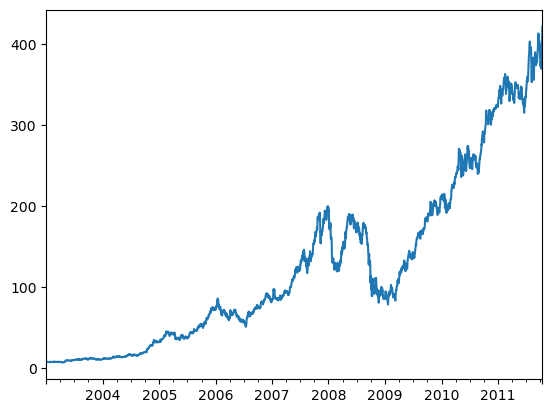

In [305]:
close_px["AAPL"].plot()

<Axes: >

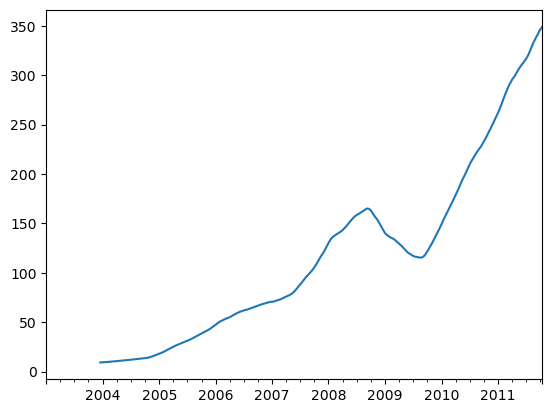

In [307]:
close_px["AAPL"].rolling(250).mean().plot()

表达式rolling(250)与groupby很像，但它不是进行分组，而是创建一个可以按照250日分组的移动窗口对象，然后就得到了apple公司的250日移动窗口。

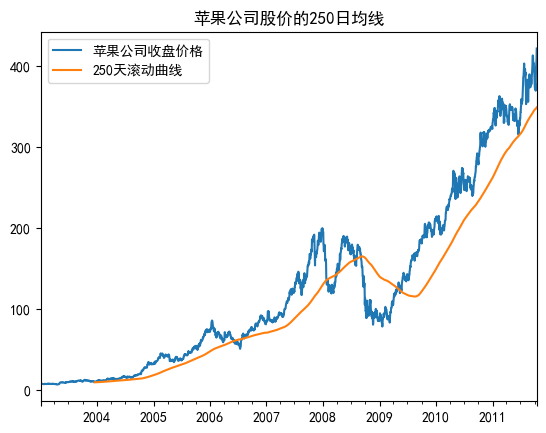

In [332]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 读取数据并将时间列设置为索引，同时解析日期
close_px_all = pd.read_csv("../examples/stock_px.csv",
                           parse_dates=True, index_col=0)

# 对数据框进行切片，选择特定的股票列
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]

# 将数据重采样为工作日（B），并使用前向填充 (ffill) 来填充缺失值
close_px = close_px.resample("B").ffill()

# 绘制 AAPL 股票的收盘价格折线图
close_px["AAPL"].plot(label="苹果公司收盘价格")

# 计算 250 天的滚动平均，并绘制该平均线
close_px["AAPL"].rolling(250).mean().plot(label="250天滚动曲线")

plt.title("苹果公司股价的250日均线")

# 添加图例，以区分原始数据和均线
plt.legend()

plt.show()

默认情况下，滚动函数需要窗口中所有的值为非NA值，可以修改此行为以解决缺失数据的问题。



图中苹果公司收盘曲线就是从第1天开始就有数据，黄色的线就是250天滚动曲线，因为前249个数不够250个，所以前249个数都为Na值，从250个开始才有滑动窗口平均值，第250个就是前250个数的平均值，后面以此类推，2~251...




特别是，实际上在时间序列开始处，数据量就低于window周期数，因为一开始会有Na值

In [325]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [336]:
# 计算 AAPL 的250天滚动标准差，基于其每日的百分比变化，并且在滚动窗口的最小数据点数为 10 的情况下计算标准差。
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()

# 选取下标为5~11的行数据
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

**为什么没有250个值却已经开始计算了？**  




因为设置了min_periods=10 允许窗口内的最小有效数据点数为 10，这意味着即使窗口中的数据点少于 250 个，只要有至少 10 个有效数据点，就会计算标准差 std()。所以从第11个开始就有数值了

pct_change()计算相邻元素之间的百分比变化。 



rolling(250, min_periods=10) 是 Pandas 中用于滚动窗口计算的方法。它允许你在一个指定的窗口大小内，对时间序列数据执行聚合运算（如求平均值、标准差等），但还提供了一个参数 min_periods 来定义在窗口内需要多少个有效数据点才能执行计算。  

Series.rolling(window, min_periods=None, center=False, win_type=None, on=None, axis=0, closed=None)

rolling() 方法创建一个滚动窗口对象，通过指定窗口大小 250 来控制每次滚动时包含的数据点数量。  
min_periods=10 确保在窗口内至少有 10 个非 NaN 数据点时才计算结果，否则返回 NaN。  


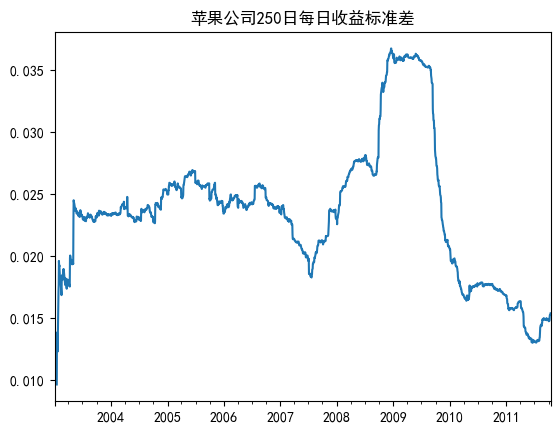

In [341]:
std250.plot()

plt.title("苹果公司250日每日收益标准差")

plt.show()

要计算扩展窗口平均值，不使用rolling，而是使用expanding运算符。**使用与滚动窗口相同的起始点，扩展窗口平均值开启时间窗口后持续增加窗口大小，直到涵盖整个序列。**

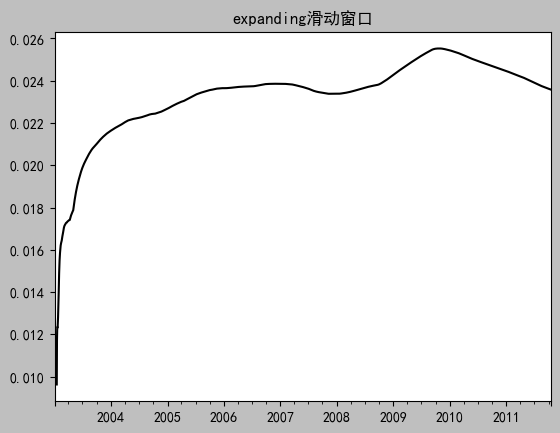

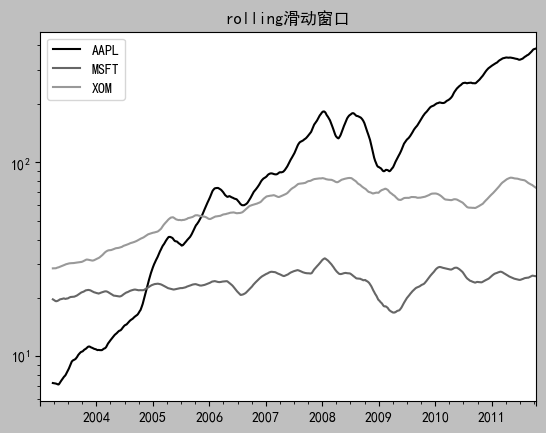

In [377]:
# std250时间序列的扩展窗口平均值如下所示:
expanding_mean = std250.expanding().mean()  # 扩展窗口操作，用于计算一个时间序列或数据的扩展窗口平均值。

plt.style.use("grayscale")

# 绘制expanding滑动窗口
expanding_mean.plot()
plt.title("expanding滑动窗口")

# 对DF调用移动窗口函数会将转化应用到所有列上
close_px.rolling(60).mean().plot(logy=True)  # 对y轴使用对数刻度，大数据时常用
plt.title("rolling滑动窗口")

plt.legend()

plt.show()

rolling函数也可以接收一个字符串，而非一组周期数字，用于给移动窗口函数的rolling（）指定固定大小的时间偏移量。使用字符串可以方便地处理不规则的时间序列。这些字符串也可以传递给resample。

In [367]:
# 计算20天的滚动均值：
close_px.rolling("20D").mean()  # D表示day

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


**rolling**



滚动窗口操作是一种在时间序列数据或其他有序数据上使用滑动窗口进行计算的技术。这个操作的基本思想是，在数据上定义一个固定大小的窗口，然后沿着数据移动这个窗口，并在每个窗口内进行一些聚合计算（例如，计算平均值、标准差、最大值、最小值等）。


平滑数据：   

分析局部统计量：    

趋势分析：    

风险和波动性分析：    



滚动窗口操作会将一个固定大小的窗口应用到数据序列的每个可能的子集。这个窗口会在每个位置计算一个值（例如，均值或标准差），并将其赋给窗口的结束点。窗口移动到下一个位置时，继续执行相同的操作。  

指数：  

窗口大小：窗口的大小决定了每次计算时使用多少个数据点。  
窗口移动：窗口从数据集的第一个位置开始，逐步向前移动一个点，每次移动时重新计算窗口内的数据。  
聚合计算：在每个窗口内，你可以执行任何聚合操作，如均值、标准差、最大值、最小值等。  

**expanding**  



用于计算扩展窗口操作。与滚动窗口（rolling()）不同，扩展窗口从时间序列的第一个数据点开始，不断扩大窗口的大小，直到包括序列中的所有数据。它的常见用途是计算累积统计量，例如累积均值、累积和、累积标准差等。



min_periods（默认是 1）：指定在计算扩展统计时，窗口内至少需要有多少个非 NaN 数据点。如果窗口内有效数据点不足 min_periods，计算结果将返回 NaN。  



与 rolling() 的区别：  
扩展窗口：expanding() 是从第一个数据点开始扩展，窗口的大小不断增加，每次计算的窗口都包含从开始到当前点的所有数据。  
滚动窗口：rolling() 则是固定窗口大小，在序列上滑动窗口，计算固定长度的数据子集。  



expanding() 是 Pandas 中用于扩展窗口计算的工具，随着时间序列的推进，窗口不断扩展，包含从开始到当前点的所有数据。  
适用于计算累积统计量，如累积均值、累积和、累积标准差等。  
通过 min_periods 参数，可以控制在窗口内数据点不足时是否计算结果。  

#### 11.7.1 指数加权函数  
另一种使用固定大小窗口及相等权重观测值的办法，是定义一个衰减因子常量，以给予最近的观测值更大的权重。



衰减因子的定义方式有很多，比较流行的是使用时间段的方式，它可以使结果类似于一个简单的移动窗口函数，且窗口大小等于时间段。  
由于指数加权统计会赋予近期观测值更大的权重，因此相对于等权统计，它对变化“适应”得更快。

加权移动均值 (Weighted Moving Average, WMA) 是一种时间序列分析方法，它对时间窗口内的观测值赋予不同的权重，通常将较大的权重分配给最近的观测值，较小的权重分配给较早的观测值。这使得加权移动均值能够更快地响应数据的变化，特别是对于短期趋势或变化的捕捉更加敏感。

WMA 的核心思想：  
不同权重：与简单移动均值 (SMA) 不同，WMA 对时间窗口内的每个数据点赋予不同的权重。权重通常是递减的，即最近的数据点权重大，而较远的数据点权重较轻。  
更快响应变化：由于最近的数据对均值的影响更大，所以 WMA 能够更快地响应数据的变化，特别是在数据剧烈波动时，这一点尤其明显。

有 n 个数据点，权重从 w1 到 wn，对应的数据为 x1 到 xn，加权移动均值的公式为：  
![jupyter](11.17.png)  
x_t：表示在时间点 t 的数据。  
w_i：是第 i 个数据点的权重，通常最近的数据权重大，远期的数据权重较小。  
权重和为 1 或其他常数：权重的总和可以设为 1 或其他数值，来平衡加权的影响。  

WMA 的计算过程：  
确定权重分配：通常，最近的观测值被赋予较大的权重，而较远的数据被赋予较小的权重。  
例如，在一个 3 天的加权移动平均中，你可以为最近的观测值分配 60% 的权重，次新的观测值分配 30%，最老的观测值分配 10%。  
加权求和：将窗口内的观测值与各自的权重相乘，然后求和。  
标准化：将加权和除以权重的总和，以获得最终的加权移动平均值。  

假设我们有一个时间序列数据，窗口大小为 3，权重分别为 [0.6, 0.3, 0.1]，代表最近的数据权重最大。
![jupyter](11.18.png)  
![jupyter](11.19.png)  
![jupyter](11.20.png)

WMA 与其他均值方法的比较：  
简单移动均值 (SMA)：所有数据点的权重相等，即每个观测值对结果的影响相同。WMA 则对最近的数据点赋予更大的权重，使得其对数据变化反应更敏感。  



指数加权移动均值 (EWMA)：与 WMA 类似，但在 EWMA 中，权重衰减是指数形式的，而 WMA 通常使用线性递减的权重。EWMA 的计算更加平滑，变化的速度较慢，但长期趋势更稳定。

WMA 的优缺点：  
优点：  
对数据变化更加敏感，能够更快地响应最近的变化。  
可以灵活调整权重，以适应不同的场景和需求。  
缺点：  
如果权重设定不当，可能过度响应数据的短期波动。  
与简单移动均值相比，WMA 计算复杂度稍高，需要设置合适的权重。  

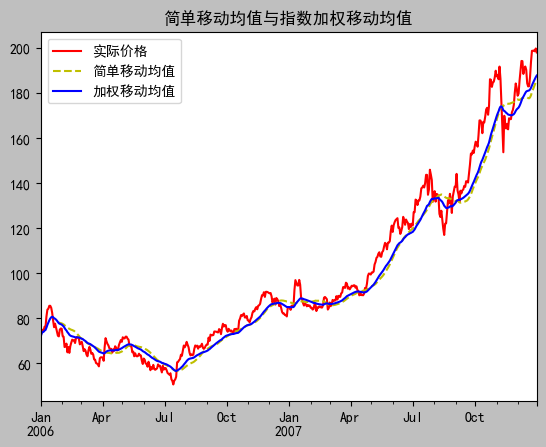

In [406]:
# 除了rolling 和 expanding，pd还有ewm运算符，ewm表示加权移动。
# apple公司股价的30日移动均值和span=60的指数加权移动均值：
aapl_px = close_px["AAPL"]["2006": "2007"]
ma30 = aapl_px.rolling(30, min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()
aapl_px.plot(style="r-", label="实际价格")
ma30.plot(style="y--", label="简单移动均值")  # ro-表示带有红点的折线
ewma30.plot(style="b", label="加权移动均值")

plt.title("简单移动均值与指数加权移动均值")

plt.legend()

plt.show()

#### 主要区别：  
**权重分配：**  

实际值：每个数据点是原始观测值，没有加权。  
简单移动均值 (SMA)：窗口内每个数据点的权重相同，等权重。  
加权移动均值 (WMA)：窗口内数据点的权重不同，通常最近的数据权重大。  




**反应速度：**  

实际值：最敏感，反映最新数据的瞬时变化。  
简单移动均值：平滑效果好，但反应速度较慢，因为它对所有数据点赋予相同的权重。  
加权移动均值：比简单移动均值对变化的反应速度更快，因为它对最近的数据赋予更大的权重。  




**滞后效应：**  

实际值：没有滞后，实时反映数据。  
简单移动均值：有滞后，因为它对最新数据的反应较慢。  
加权移动均值：滞后效应较小，因为它对最近数据赋予更大的权重。  




**适用场景：**  
实际值：适合即时展示数据，但可能波动较大，难以观察趋势。  
简单移动均值 (SMA)：适合观察数据的总体趋势，平滑短期波动，但反应慢。  
加权移动均值 (WMA)：适合需要快速反应的数据分析，特别是当你希望对近期数据赋予更大权重时。  




**总结：**  
实际值：代表的是原始数据，无平滑、无权重。  
简单移动均值 (SMA)：窗口内每个数据点权重相等，对数据平滑处理，**适合识别长期趋势**，但对近期变化反应较慢。  
加权移动均值 (WMA)：最近数据点权重大，更快响应变化，**适合对短期趋势或快速变化**的数据进行分析。  

#### 11.7.2 二元移动窗口函数  
有些统计运算（如相关系数和协方差）需要在两个时间序列上执行。  
例如，金融分析师通常对某只股票与某个基准指数（如标准普尔500指数）的相关系数感兴趣。  

[]

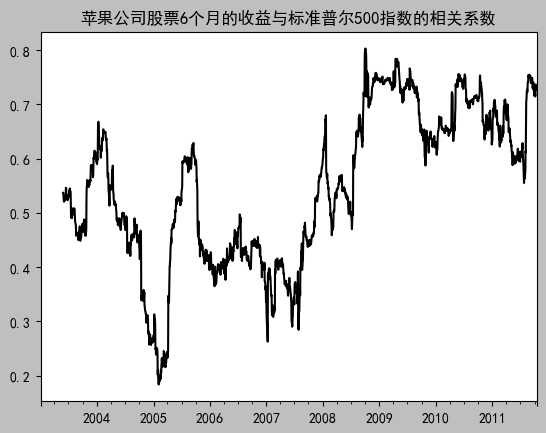

In [447]:
# 要进行说明，先计算所有的时间序列的百分比变化：
spx_px = close_px_all["SPX"]  # SPX就是标准普尔500指数
spx_rets = spx_px.pct_change()  # 计算标准普尔500指数的百分比变化
returns = close_px.pct_change()  # 计算所有股票的百分比变化，包括AAPL

# 调用rolling后，corr聚合函数开始计算spx_rets的滚动相关系数
# 滚动窗口，大小为 125 个时间点（大约是 6 个月的交易日），至少有 100 个有效数据点才能计算结果。
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)

plt.title("苹果公司股票6个月的收益与标准普尔500指数的相关系数")

corr.plot()

plt.plot()

一次性计算多只股票与标准普尔500指数的相关系数，可以编写一个循环，像对苹果股票那样，对每只股票进行计算。但如果每只股票都是DataFrame中的一列，我们只需对DataFrame和传入的Series spx_rets调用rolling，就可以一次性计算出所有的滚动相关系数:

[]

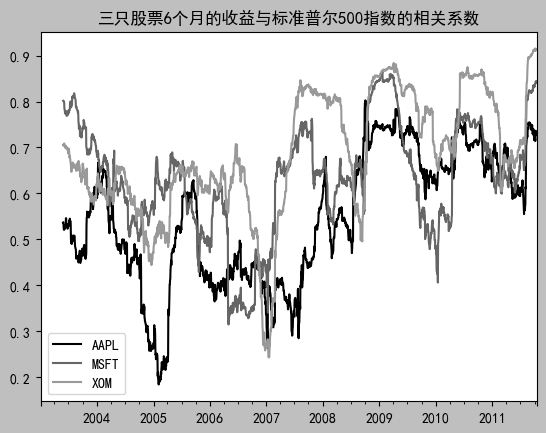

In [455]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

plt.title("三只股票6个月的收益与标准普尔500指数的相关系数")

plt.plot()

#### 11.7.3 用户自定义的移动窗口函数  
在rolling及其相关方法上使用apply方法，提供了一种能够在移动窗口上应用自己定义的数组函数的途径。唯一的要求是该函数要能从数组的各个片段中产生单个值（即约简）。



例如，当我们用rolling（...）.quantile（q）计算样本分位数时，可能对样本中特定值的百分等级感兴趣。scipy.stats.percentileofscore函数就能实现这个目的:

[]

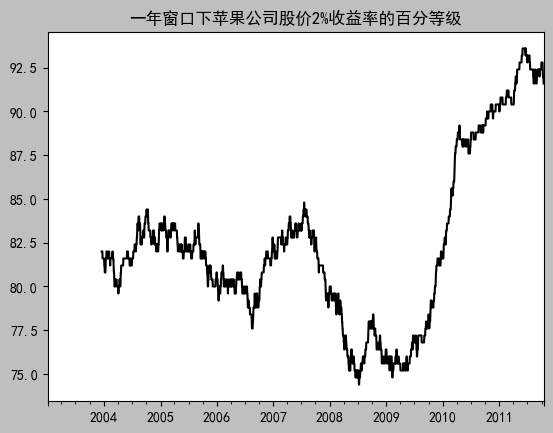

In [466]:
from scipy.stats import percentileofscore

# 大于样本中2%的数据
def score_at_2percent(x):
    return percentileofscore(x, 0.02)

result = returns["AAPL"].rolling(250).apply(score_at_2percent)

result.plot()

plt.title("一年窗口下苹果公司股价2%收益率的百分等级")

plt.plot()

percentileofscore 是 SciPy 提供的一个函数，用于计算给定数据集中某个值（在这里是 2%）相对于所有数据的百分等级。  
百分等级表示数据在给定样本中处于什么位置。例如，如果某个数值的百分等级为 90%，则意味着它大于样本中 90% 的数据。

滚动窗口计算：每次在一个 250 天的滚动窗口内，计算苹果公司股票收益率为 2% 时的百分等级。这表示在过去一年中，2% 的收益率在所有收益率中的相对位置。

百分等级：百分等级（percentile）表示一个值相对于整个数据集中的位置。例如，2% 的收益率可能在某些窗口中处于非常高的百分等级，意味着它在过去 250 天内很少出现；而在某些窗口中，2% 的收益率可能处于低百分等级，意味着它经常出现。